# Traffic Sign Classification — Full ML Pipeline

**Dataset:** Australian Traffic Sign Recognition Benchmark (Google Drive)  
**Task:** Multi-class image classification — 15 classes  
**Approach:** Custom CNN trained from scratch — NO transfer learning  


---
### Pipeline Steps
```
Step 1  → Mount Google Drive & verify dataset
Step 2  → Import libraries & global config
Step 3  → Dataset analysis & exploration
Step 4  → Data visualizations
Step 5  → Preprocessing & smart tf.data pipeline
           (directional signs: no flip / no rotate)
Step 6  → Model architecture (custom CNN)
Step 7  → Training
Step 8  → Training visualizations
Step 9  → Evaluation & confusion matrix
Step 10 → Prediction demo
Step 11 → Save results
```

---
## Step 1: Mount Google Drive & Verify Dataset

In [18]:
# Mount Google Drive — your dataset lives here permanently
# No re-downloading needed every session
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted successfully')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully


In [19]:
import shutil, os
from pathlib import Path

# Copy dataset from slow Google Drive → fast Colab local SSD
# This takes 3-5 minutes once, but then training is 10x faster

DRIVE_DATASET = '/content/drive/MyDrive/Traffic CNN/Traffic Data'
LOCAL_DATASET = '/content/traffic_data'

if not Path(LOCAL_DATASET).exists():
    print("Copying dataset from Drive to local SSD...")
    print("This takes 3-5 minutes but training will be much faster...")
    shutil.copytree(DRIVE_DATASET, LOCAL_DATASET)
    print("Copy done!")
else:
    print("Dataset already on local SSD - skipping copy")

# Verify
classes = [d.name for d in Path(LOCAL_DATASET).iterdir() if d.is_dir()]
print(f"Classes on local disk: {len(classes)}")

Copying dataset from Drive to local SSD...
This takes 3-5 minutes but training will be much faster...
Copy done!
Classes on local disk: 15


In [22]:
from pathlib import Path

# ── Path to your dataset on Google Drive
# Structure: Traffic Data/Traffic Data/{class_name}/{images}
DATASET_ROOT = Path('/content/traffic_data')

# ── Verify the dataset is accessible
if not DATASET_ROOT.exists():
    raise FileNotFoundError(f'Dataset not found at: {DATASET_ROOT}\nCheck your Google Drive path.')

classes_found = sorted([d.name for d in DATASET_ROOT.iterdir() if d.is_dir()])

print(f'Dataset root  : {DATASET_ROOT}')
print(f'Classes found : {len(classes_found)}')
for c in classes_found:
    count = len(list((DATASET_ROOT / c).rglob('*')))
    print(f'  {c:<25} {count} files')

Dataset root  : /content/traffic_data
Classes found : 15
  exitleft                  302 files
  exitright                 6126 files
  giveway                   4889 files
  noentry                   3681 files
  noovertaking              769 files
  oneway                    2701 files
  pedestrian                1065 files
  roundabout                1211 files
  speedlimit100             2880 files
  speedlimit20              1099 files
  speedlimit60              3056 files
  stop                      2615 files
  trafficsignalahead        1629 files
  turnleft                  1384 files
  turnright                 804 files


---
## Step 2: Import Libraries & Global Config

In [23]:
import os, random, json
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter

import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image

# ── Reproducibility: fix all random seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Hyperparameters
IMG_SIZE      = 64
BATCH_SIZE    = 64
EPOCHS        = 80
LEARNING_RATE = 0.001
VAL_SPLIT     = 0.15
TEST_SPLIT    = 0.10

# ── Save model to Colab local (fast I/O), download at the end
MODEL_DIR = '/content/models'
os.makedirs(MODEL_DIR, exist_ok=True)

# ── GPU check
gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs available: {len(gpus)}')
if not gpus:
    print('  WARNING: No GPU. Go to Runtime > Change runtime type > GPU')
print(f'Config  IMG={IMG_SIZE}  BATCH={BATCH_SIZE}  EPOCHS={EPOCHS}  LR={LEARNING_RATE}')

GPUs available: 1
Config  IMG=64  BATCH=64  EPOCHS=80  LR=0.001


---
## Step 3: Dataset Analysis & Exploration

In [24]:
# ── Collect every image path and its class label
VALID_EXT = {'.png', '.jpg', '.jpeg', '.bmp', '.webp'}

image_paths, labels = [], []
for class_dir in sorted(DATASET_ROOT.iterdir()):
    if not class_dir.is_dir():
        continue
    class_name = class_dir.name
    imgs = [str(p) for p in class_dir.rglob('*') if p.suffix.lower() in VALID_EXT]
    image_paths.extend(imgs)
    labels.extend([class_name] * len(imgs))

# ── Build DataFrame
df = pd.DataFrame({'filepath': image_paths, 'label': labels})

# ── Encode class names to integers
CLASS_NAMES  = sorted(df['label'].unique().tolist())
NUM_CLASSES  = len(CLASS_NAMES)
class_to_idx = {name: idx for idx, name in enumerate(CLASS_NAMES)}
idx_to_class = {idx: name for name, idx in class_to_idx.items()}
df['label_idx'] = df['label'].map(class_to_idx)

# ── Identify directional sign indices
# These signs are identified ONLY by arrow direction
# Flipping or rotating them changes their meaning completely:
#   oneway    = upward arrow
#   turnleft  = left curved arrow
#   turnright = right curved arrow
#   exitleft  = left downward arrow
#   exitright = right downward arrow
DIRECTIONAL_CLASSES = {'oneway', 'turnleft', 'turnright', 'exitleft', 'exitright'}
DIRECTIONAL_INDICES = set(class_to_idx[c] for c in DIRECTIONAL_CLASSES if c in class_to_idx)

print(f'Total images  : {len(df):,}')
print(f'Total classes : {NUM_CLASSES}')
print(f'\nDirectional signs (NO flip / NO rotate during augmentation):')
for c in DIRECTIONAL_CLASSES:
    if c in class_to_idx:
        print(f'  [{class_to_idx[c]:>2}] {c}')
print()
counts = df['label'].value_counts().sort_values(ascending=False)
for cls, cnt in counts.items():
    bar = '#' * (cnt // 200)
    print(f'  {cls:<25} {cnt:>5}  {bar}')

Total images  : 34,211
Total classes : 15

Directional signs (NO flip / NO rotate during augmentation):
  [ 1] exitright
  [ 5] oneway
  [13] turnleft
  [14] turnright
  [ 0] exitleft

  exitright                  6126  ##############################
  giveway                    4889  ########################
  noentry                    3681  ##################
  speedlimit60               3056  ###############
  speedlimit100              2880  ##############
  oneway                     2701  #############
  stop                       2615  #############
  trafficsignalahead         1629  ########
  turnleft                   1384  ######
  roundabout                 1211  ######
  speedlimit20               1099  #####
  pedestrian                 1065  #####
  turnright                   804  ####
  noovertaking                769  ###
  exitleft                    302  #


---
## Step 4: Data Visualizations

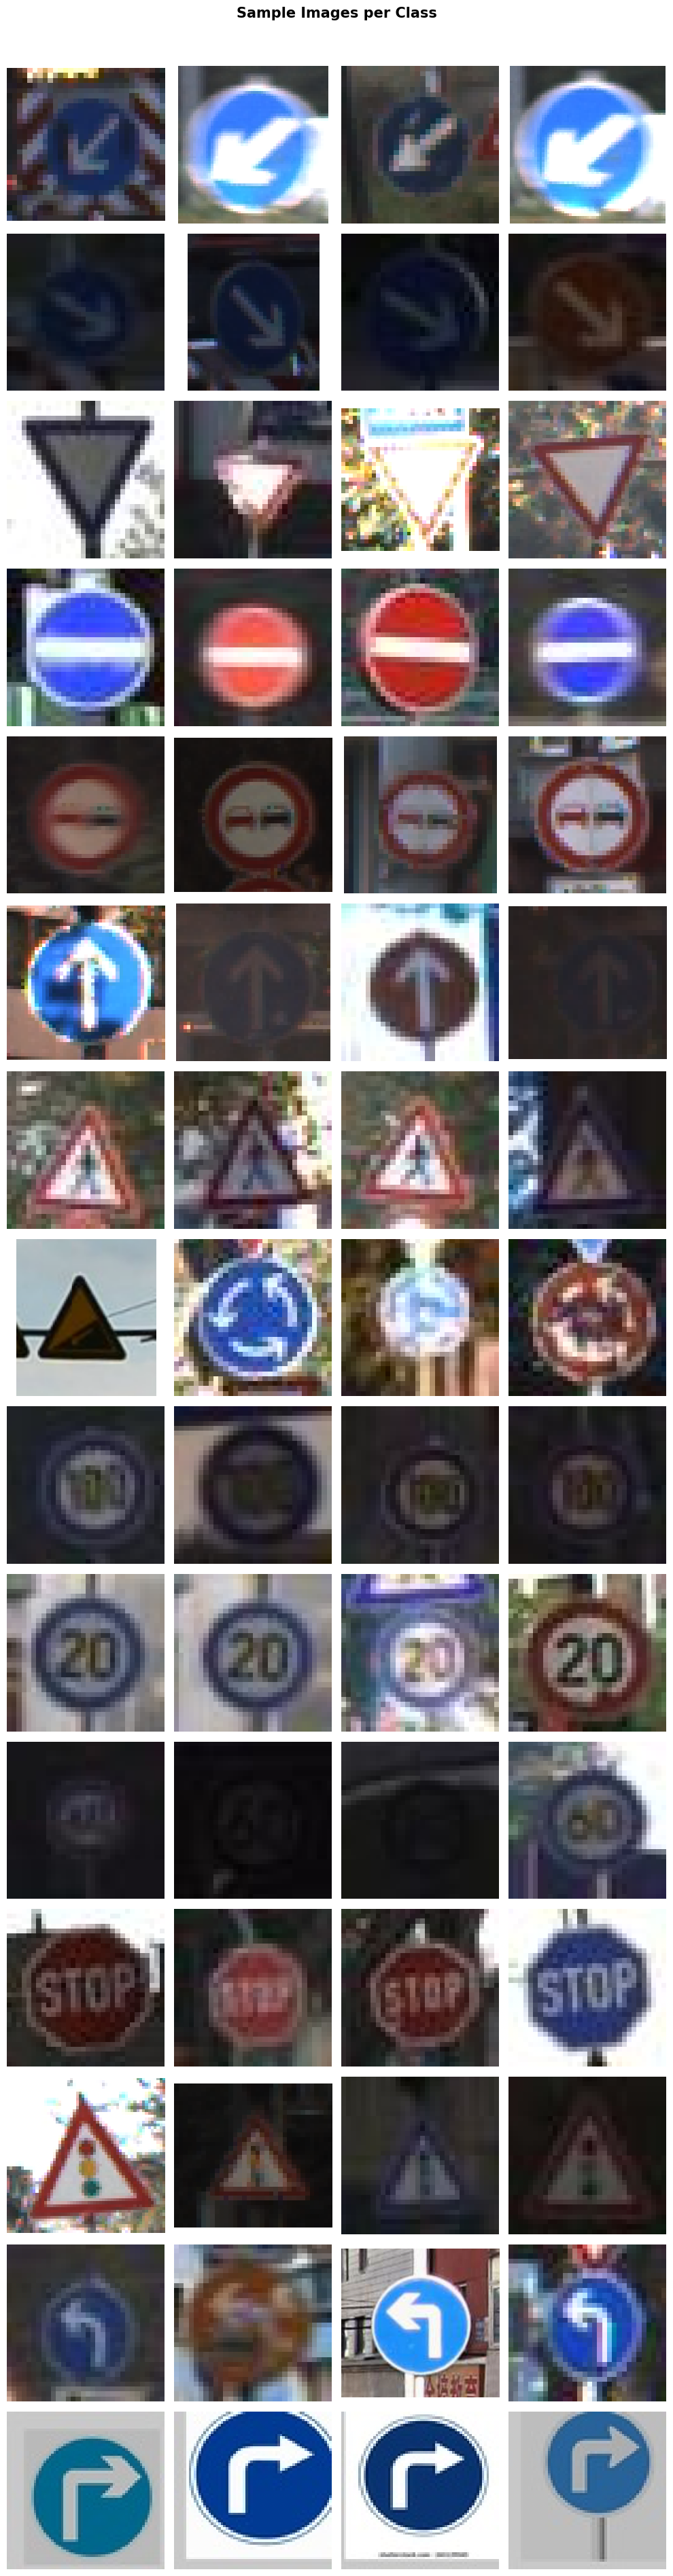

* = directional sign (arrow direction must be preserved in augmentation)


In [26]:
# ── VIZ 2: Sample images per class
SAMPLES = 4
fig, axes = plt.subplots(NUM_CLASSES, SAMPLES, figsize=(SAMPLES * 2.5, NUM_CLASSES * 2.5))
fig.suptitle('Sample Images per Class', fontsize=15, fontweight='bold', y=1.01)

for row, cls in enumerate(CLASS_NAMES):
    paths = df[df['label'] == cls]['filepath'].tolist()
    picks = random.sample(paths, min(SAMPLES, len(paths)))
    for col, path in enumerate(picks):
        ax = axes[row][col]
        ax.imshow(Image.open(path).convert('RGB'))
        ax.axis('off')
        if col == 0:
            # Mark directional signs clearly
            label_text = f'{cls} *' if cls in DIRECTIONAL_CLASSES else cls
            ax.set_ylabel(label_text, fontsize=8, fontweight='bold',
                          rotation=0, labelpad=65, va='center',
                          color='red' if cls in DIRECTIONAL_CLASSES else 'black')

plt.tight_layout()
plt.savefig('/content/viz_sample_images.png', dpi=120, bbox_inches='tight')
plt.show()
print('* = directional sign (arrow direction must be preserved in augmentation)')

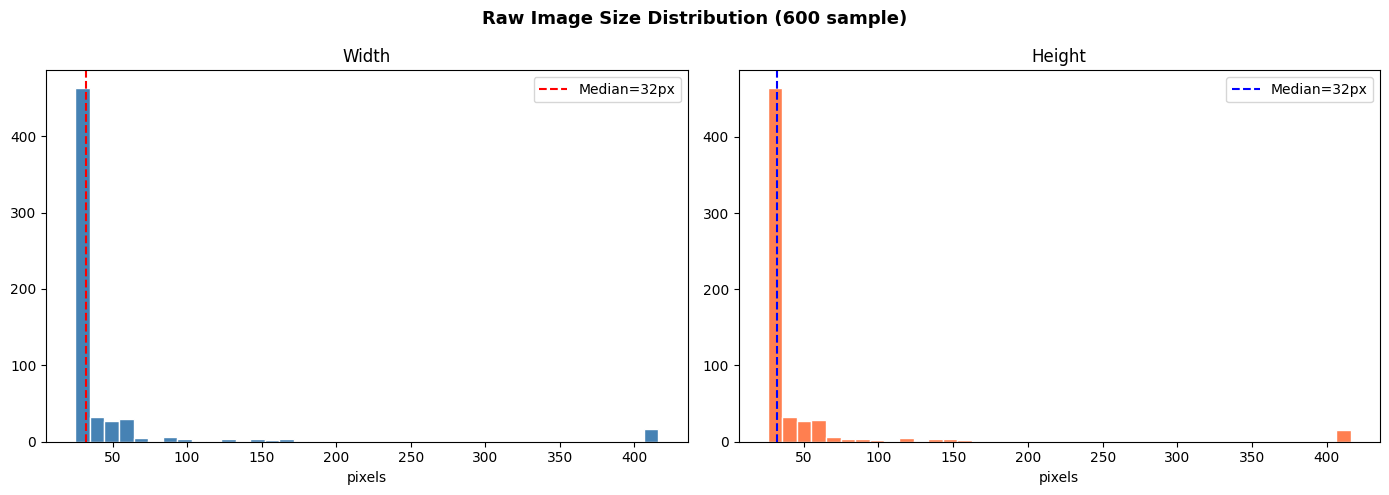

All images resized to 64x64 for uniform model input.


In [27]:
# ── VIZ 3: Raw image size distribution
sample_paths = df['filepath'].sample(n=min(600, len(df)), random_state=SEED).tolist()
widths, heights = [], []
for p in sample_paths:
    try:
        w, h = Image.open(p).size
        widths.append(w)
        heights.append(h)
    except Exception:
        pass

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Raw Image Size Distribution (600 sample)', fontsize=13, fontweight='bold')

axes[0].hist(widths,  bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(np.median(widths),  color='red', linestyle='--',
                label=f'Median={np.median(widths):.0f}px')
axes[0].set_title('Width');  axes[0].set_xlabel('pixels');  axes[0].legend()

axes[1].hist(heights, bins=40, color='coral',    edgecolor='white')
axes[1].axvline(np.median(heights), color='blue', linestyle='--',
                label=f'Median={np.median(heights):.0f}px')
axes[1].set_title('Height'); axes[1].set_xlabel('pixels'); axes[1].legend()

plt.tight_layout()
plt.savefig('/content/viz_image_sizes.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'All images resized to {IMG_SIZE}x{IMG_SIZE} for uniform model input.')

---
## Step 5: Data Preprocessing & Smart tf.data Pipeline

### Key Design: Direction-Aware Augmentation

Five classes are identified **solely by arrow direction**:

| Class | Arrow | Why direction matters |
|---|---|---|
| `oneway` | Upward | Flip → downward (wrong) |
| `turnleft` | Left curved | Flip → turnright (wrong class) |
| `turnright` | Right curved | Flip → turnleft (wrong class) |
| `exitleft` | Left downward | Flip → exitright (wrong class) |
| `exitright` | Right downward | Flip → exitleft (wrong class) |

**Solution:** The augmentation function checks each image's label and applies:
- **Directional signs** → brightness, contrast, zoom, translate only (NO flip, NO rotate)
- **Non-directional signs** → full augmentation including flip and rotation

In [28]:
all_paths  = df['filepath'].tolist()
all_labels = df['label_idx'].tolist()

# ── Split: test 10%, val 15%, train 75%
# stratify= keeps class proportions equal in every split
train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
    all_paths, all_labels,
    test_size=TEST_SPLIT, random_state=SEED, stratify=all_labels
)

val_fraction = VAL_SPLIT / (1 - TEST_SPLIT)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths, train_val_labels,
    test_size=val_fraction, random_state=SEED, stratify=train_val_labels
)

print(f'Train : {len(train_paths):,} images  ({len(train_paths)/len(df)*100:.1f}%)')
print(f'Val   : {len(val_paths):,} images  ({len(val_paths)/len(df)*100:.1f}%)')
print(f'Test  : {len(test_paths):,} images  ({len(test_paths)/len(df)*100:.1f}%)')

Train : 25,657 images  (75.0%)
Val   : 5,132 images  (15.0%)
Test  : 3,422 images  (10.0%)


In [29]:
# ── Class weights
# Formula: total_images / (num_classes x images_in_class)
# Rare class → high weight → mistakes hurt more → model forced to learn it
weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_labels
)
class_weight_dict = {i: float(w) for i, w in enumerate(weights_array)}

print('Class weights (higher = rarer class):')
for idx, w in sorted(class_weight_dict.items(), key=lambda x: -x[1]):
    marker = '  [DIRECTIONAL]' if idx in DIRECTIONAL_INDICES else ''
    print(f'  [{idx:>2}] {CLASS_NAMES[idx]:<25} {w:.3f}{marker}')

Class weights (higher = rarer class):
  [ 0] exitleft                  7.535  [DIRECTIONAL]
  [ 4] noovertaking              2.964
  [14] turnright                 2.837  [DIRECTIONAL]
  [ 6] pedestrian                2.143
  [ 9] speedlimit20              2.076
  [ 7] roundabout                1.884
  [13] turnleft                  1.648  [DIRECTIONAL]
  [12] trafficsignalahead        1.400
  [11] stop                      0.872
  [ 5] oneway                    0.844  [DIRECTIONAL]
  [ 8] speedlimit100             0.792
  [10] speedlimit60              0.746
  [ 3] noentry                   0.620
  [ 2] giveway                   0.467
  [ 1] exitright                 0.372  [DIRECTIONAL]


In [30]:
AUTOTUNE = tf.data.AUTOTUNE

# ── Convert directional indices to a TensorFlow constant tensor
# This allows checking inside the tf.data pipeline (which runs as a TF graph)
DIRECTIONAL_TENSOR = tf.constant(sorted(list(DIRECTIONAL_INDICES)), dtype=tf.int32)

# ── Keras augmentation layers — created ONCE, reused for every image
# Creating layers inside the function would create new objects for every image (slow)
rotation_layer    = keras.layers.RandomRotation(0.10)
zoom_layer        = keras.layers.RandomZoom(0.15)
translation_layer = keras.layers.RandomTranslation(0.10, 0.10)


def load_image(filepath, label):
    """
    Load one image from disk and prepare it for the model.
      1. Read raw bytes from file
      2. Decode into pixel tensor (H x W x 3)
      3. Resize to IMG_SIZE x IMG_SIZE
      4. Normalize: 0-255 integers → 0.0-1.0 floats
         (smaller values = more stable gradient descent)
    """
    raw   = tf.io.read_file(filepath)
    image = tf.image.decode_image(raw, channels=3, expand_animations=False)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label


def augment(image, label):
    """
    Direction-aware augmentation — applied to TRAINING images only.

    DIRECTIONAL SIGNS (oneway, turnleft, turnright, exitleft, exitright):
      These signs are identified ONLY by which side the arrow points.
      Flipping mirrors left↔right → turnright becomes turnleft (wrong label).
      Rotating tilts the arrow → changes perceived direction (wrong label).
      SAFE augmentations: brightness, contrast, saturation only.

    NON-DIRECTIONAL SIGNS (stop, giveway, roundabout, etc.):
      Symmetric signs — flipping and rotating do not change meaning.
      Full augmentation: flip + rotate + zoom + translate + brightness etc.
    """
    # Check if this image's label is a directional sign
    # tf.reduce_any checks if label matches ANY value in DIRECTIONAL_TENSOR
    label_int      = tf.cast(label, tf.int32)
    is_directional = tf.reduce_any(tf.equal(DIRECTIONAL_TENSOR, label_int))

    # ── Augmentations SAFE for ALL signs (do not change arrow direction)
    image = tf.image.random_brightness(image, max_delta=0.20)
    image = tf.image.random_contrast(image, lower=0.80, upper=1.20)
    image = tf.image.random_saturation(image, lower=0.80, upper=1.20)

    # ── Augmentations UNSAFE for directional signs
    # tf.cond: if is_directional → skip; else → apply
    # Random horizontal flip: mirrors image left↔right
    #   Safe for: stop, giveway, roundabout (symmetric)
    #   UNSAFE for: turnleft↔turnright, exitleft↔exitright (swaps class!)
    image = tf.cond(
        is_directional,
        lambda: image,                                    # skip flip
        lambda: tf.image.random_flip_left_right(image)   # apply flip
    )

    # Random rotation and zoom/translate via Keras layers
    #   Rotation tilts arrow direction — unsafe for directional signs
    #   Zoom and translate are safe for all signs (small values)
    image = tf.expand_dims(image, 0)  # (H,W,3) → (1,H,W,3) for Keras layers

    image = tf.cond(
        is_directional,
        lambda: zoom_layer(image, training=True),         # zoom only (safe)
        lambda: rotation_layer(                           # full: rotate + zoom
                    zoom_layer(image, training=True),
                    training=True)
    )

    # Translation is safe for all signs (just shifts position, not direction)
    image = translation_layer(image, training=True)
    image = tf.squeeze(image, 0)      # (1,H,W,3) → (H,W,3)

    # Clip to [0,1] — brightness/contrast can push values outside valid range
    # Without this: pixels > 1.0 or < 0.0 cause black/washed-out images
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label


def make_dataset(paths, labels, augment_data=False, shuffle=False):
    """
    Build a tf.data pipeline:
      paths → load images in parallel → (augment) → batch → prefetch

    AUTOTUNE: TensorFlow automatically picks how many CPU threads to use.
    prefetch: loads the next batch while GPU trains on the current one.
    """
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(train_paths, train_labels, augment_data=True,  shuffle=True)
val_ds   = make_dataset(val_paths,   val_labels,   augment_data=False, shuffle=False)
test_ds  = make_dataset(test_paths,  test_labels,  augment_data=False, shuffle=False)

print(f'Train batches : {len(train_ds)}')
print(f'Val batches   : {len(val_ds)}')
print(f'Test batches  : {len(test_ds)}')

# Sanity check — verify shape and pixel range
for imgs, lbls in train_ds.take(1):
    print(f'Batch shape   : {imgs.shape}   (should be 64 x {IMG_SIZE} x {IMG_SIZE} x 3)')
    print(f'Pixel range   : [{imgs.numpy().min():.3f}, {imgs.numpy().max():.3f}]  (should be 0-1)')

Train batches : 401
Val batches   : 81
Test batches  : 54
Batch shape   : (64, 64, 64, 3)   (should be 64 x 64 x 64 x 3)
Pixel range   : [0.000, 1.000]  (should be 0-1)


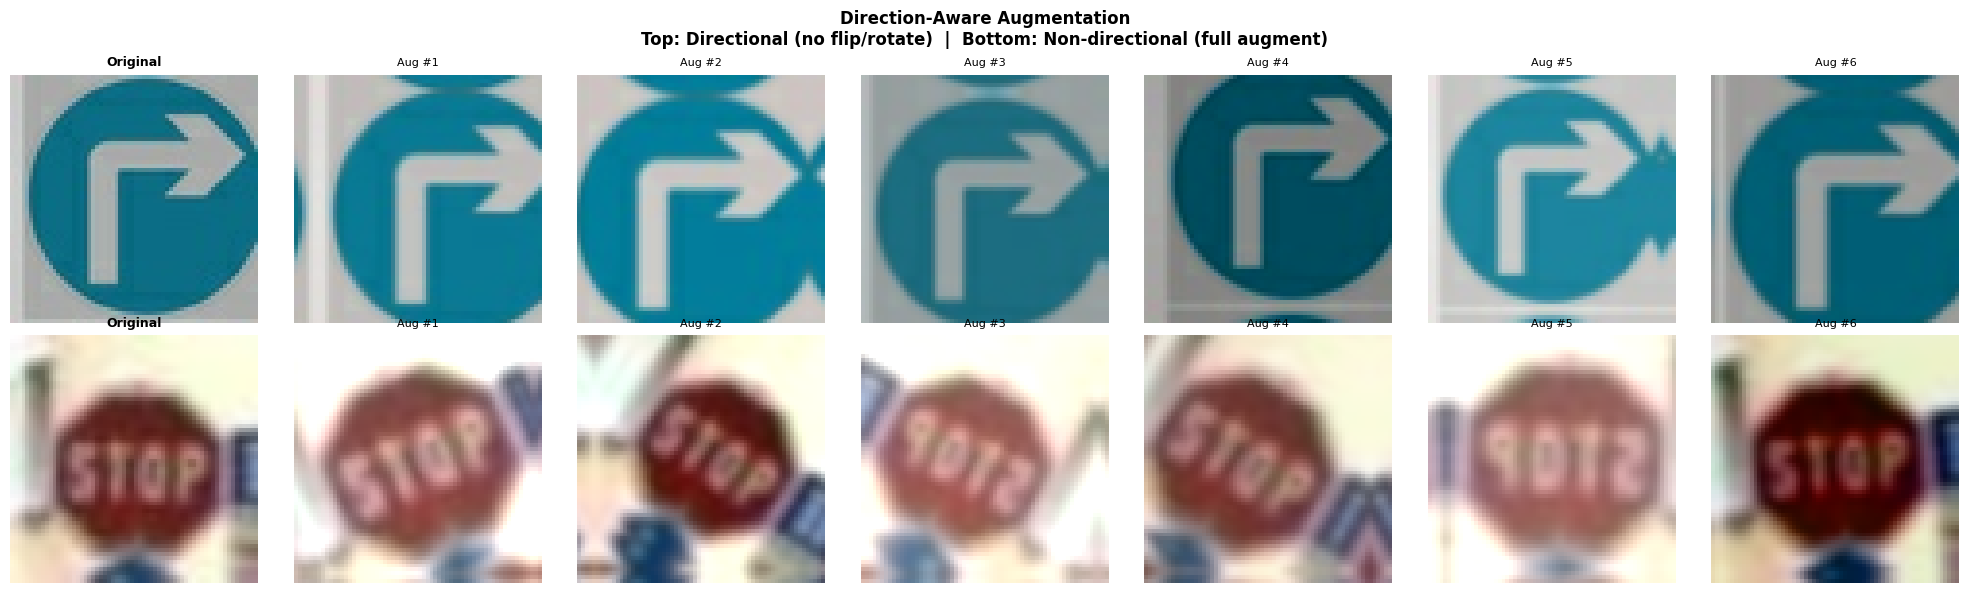

Verify: turnright arrows should ALWAYS point right across all augmented versions.
Stop signs can be flipped (symmetric) — direction does not matter.


In [31]:
# ── VIZ 4: Augmentation — show direction-aware behaviour
# Visualize one directional sign and one non-directional sign side by side
# so you can confirm directional signs are NOT being flipped

fig, axes = plt.subplots(2, 7, figsize=(20, 6))
fig.suptitle('Direction-Aware Augmentation\nTop: Directional (no flip/rotate)  |  Bottom: Non-directional (full augment)',
             fontsize=12, fontweight='bold')

# Pick one directional and one non-directional class
dir_cls    = 'turnright'
nondir_cls = 'stop'

for row_idx, cls in enumerate([dir_cls, nondir_cls]):
    paths_cls  = df[df['label'] == cls]['filepath'].tolist()
    label_idx  = class_to_idx[cls]
    sample_path = random.choice(paths_cls)
    orig_img, orig_lbl = load_image(sample_path, label_idx)

    # Original
    axes[row_idx, 0].imshow(orig_img.numpy())
    axes[row_idx, 0].set_title('Original', fontsize=9, fontweight='bold')
    axes[row_idx, 0].set_ylabel(
        f'{cls}\n(DIRECTIONAL)' if cls in DIRECTIONAL_CLASSES else f'{cls}\n(non-directional)',
        fontsize=8, color='red' if cls in DIRECTIONAL_CLASSES else 'green'
    )
    axes[row_idx, 0].axis('off')

    # 6 augmented versions
    for col in range(1, 7):
        aug_img, _ = augment(orig_img, orig_lbl)
        axes[row_idx, col].imshow(aug_img.numpy())
        axes[row_idx, col].set_title(f'Aug #{col}', fontsize=8)
        axes[row_idx, col].axis('off')

plt.tight_layout()
plt.savefig('/content/viz_augmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Verify: turnright arrows should ALWAYS point right across all augmented versions.')
print('Stop signs can be flipped (symmetric) — direction does not matter.')

---
## Step 6: Model Architecture — Custom CNN

Five convolutional blocks (32→64→128→256→512 filters).  
Each block: Conv → BatchNorm → ReLU → Conv → BatchNorm → ReLU → MaxPool → Dropout.  
Ends with Global Average Pooling + two Dense layers + Softmax output.  
**No transfer learning — every weight learned from scratch.**

In [32]:
def build_cnn(num_classes, img_size):
    reg = regularizers.l2(5e-4)  # L2 weight regularisation — discourages large weights

    inputs = keras.Input(shape=(img_size, img_size, 3))

    # ── Block 1: 32 filters — learns edges, colours, basic textures
    x = layers.Conv2D(32, 3, padding='same', kernel_regularizer=reg)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, 3, padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)   # 64x64 → 32x32
    x = layers.Dropout(0.20)(x)

    # ── Block 2: 64 filters — learns corners, gradients, simple shapes
    x = layers.Conv2D(64, 3, padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, 3, padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)   # 32x32 → 16x16
    x = layers.Dropout(0.25)(x)

    # ── Block 3: 128 filters — learns shapes like circles, arrow outlines
    x = layers.Conv2D(128, 3, padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, 3, padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)   # 16x16 → 8x8
    x = layers.Dropout(0.30)(x)

    # ── Block 4: 256 filters — learns sign-specific high-level patterns
    x = layers.Conv2D(256, 3, padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(256, 3, padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)   # 8x8 → 4x4
    x = layers.Dropout(0.30)(x)

    # ── Block 5: 512 filters — learns abstract discriminative features
    x = layers.Conv2D(512, 3, padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(512, 3, padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.35)(x)

    # ── Global Average Pooling
    # Averages each 4x4 feature map to one number → output: (512,)
    # Better than Flatten: fewer parameters + spatial invariance
    x = layers.GlobalAveragePooling2D()(x)

    # ── Classifier head
    x = layers.Dense(512, kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.45)(x)

    x = layers.Dense(256, kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.35)(x)

    # ── Output: one neuron per class, softmax converts to probabilities
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name='TrafficSign_CNN')


model = build_cnn(NUM_CLASSES, IMG_SIZE)
model.summary()
print(f'\nTotal parameters: {model.count_params():,}')

Model: "TrafficSign_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 5,121,071 (19.54 MB)

 Trainable params: 5,115,567 (19.51 MB)

 Non-trainable params: 5,504 (21.50 KB)


Total parameters: 5,121,071


In [33]:
# ── Compile
# optimizer : Adam adapts learning rate per parameter automatically
# loss      : sparse_categorical_crossentropy — standard for multi-class
#             'sparse' = labels are integers, not one-hot vectors
# metrics   : accuracy = fraction of correctly classified images
model.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print('Model compiled and ready to train.')

Model compiled and ready to train.


---
## Step 7: Training

| Callback | Purpose |
|---|---|
| `EarlyStopping` | Stops when val_accuracy stops improving — prevents overfitting |
| `ReduceLROnPlateau` | Shrinks learning rate when stuck on a plateau |
| `ModelCheckpoint` | Saves model every time val_accuracy reaches a new best |

In [34]:
BEST_MODEL_PATH = f'{MODEL_DIR}/best_model.keras'

callbacks = [
    # Stop training if val_accuracy hasn't improved for 12 epochs
    # restore_best_weights=True → load best epoch weights at the end
    EarlyStopping(monitor='val_accuracy', patience=12,
                  restore_best_weights=True, verbose=1),

    # If val_accuracy plateaus for 6 epochs → multiply LR by 0.3
    # Smaller LR = smaller steps → can escape plateaus
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.3,
                      patience=6, min_lr=1e-7, verbose=1),

    # Save model whenever val_accuracy reaches a new best
    ModelCheckpoint(filepath=BEST_MODEL_PATH, monitor='val_accuracy',
                    save_best_only=True, verbose=1),
]

print('Starting training...')
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks,
    class_weight=class_weight_dict,  # compensate for class imbalance
    verbose=1
)

print(f'\nTraining complete')
print(f'Epochs trained   : {len(history.history["accuracy"])}')
print(f'Best val accuracy: {max(history.history["val_accuracy"]):.4f}')

Starting training...
Epoch 1/80
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.1303 - loss: 3.8318
Epoch 1: val_accuracy improved from None to 0.14030, saving model to /content/models/best_model.keras

Epoch 1: finished saving model to /content/models/best_model.keras
401/401 ━━━━━━━━━━━━━━━━━━━━ 134s 278ms/step - accuracy: 0.1485 - loss: 3.5560 - val_accuracy: 0.1403 - val_loss: 3.2659 - learning_rate: 0.0010
Epoch 2/80
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.3110 - loss: 2.6123
Epoch 2: val_accuracy improved from 0.14030 to 0.60171, saving model to /content/models/best_model.keras

Epoch 2: finished saving model to /content/models/best_model.keras
401/401 ━━━━━━━━━━━━━━━━━━━━ 81s 202ms/step - accuracy: 0.4496 - loss: 2.2080 - val_accuracy: 0.6017 - val_loss: 1.7784 - learning_rate: 0.0010
Epoch 3/80
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.7613 - loss: 1.3830
Epoch 3: val_accuracy did not improve from 0.60171
401/401 ━━━━━━━━━━━━━━━━━━━━ 80s

---
## Step 8: Training Visualizations

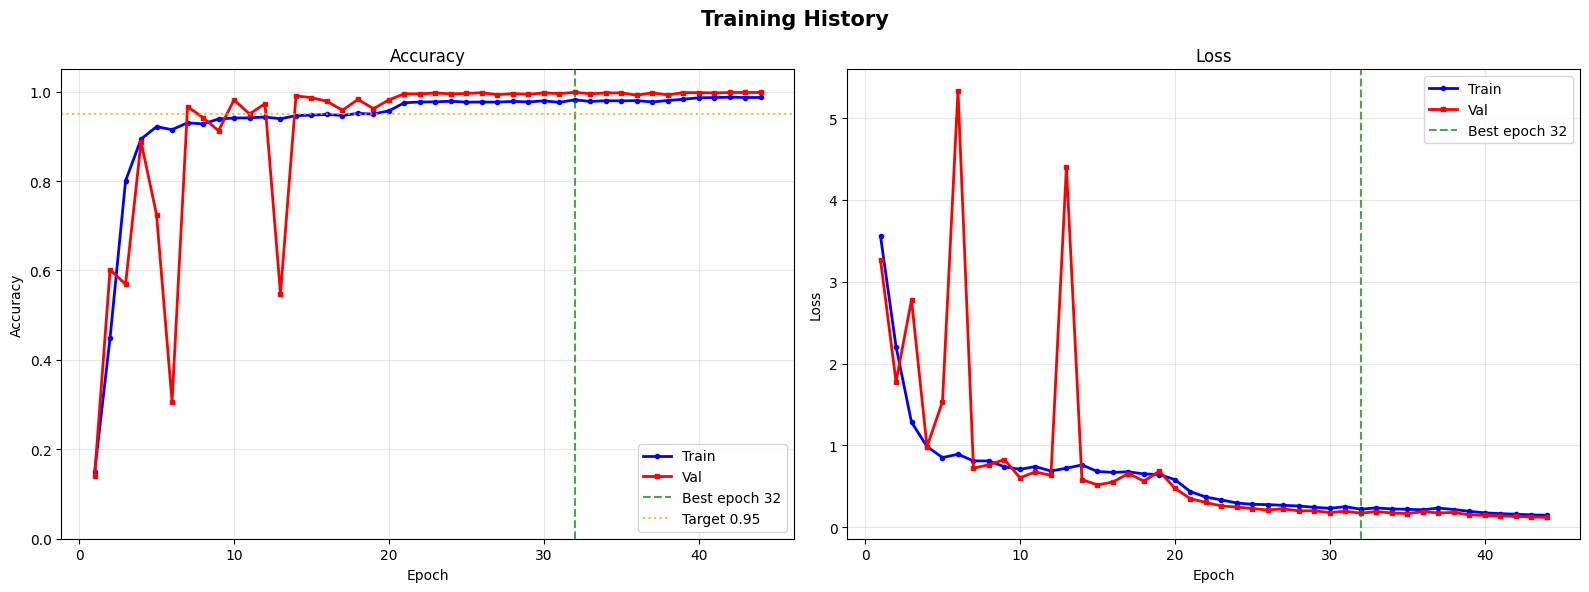

Train-Val gap: -0.0116  (Good fit)


In [35]:
# ── VIZ 5: Loss & Accuracy curves
# Good fit  : train ≈ val, both high
# Overfit   : train >> val
# Underfit  : both low

hist    = history.history
ep      = range(1, len(hist['accuracy']) + 1)
best_ep = np.argmax(hist['val_accuracy']) + 1

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Training History', fontsize=15, fontweight='bold')

axes[0].plot(ep, hist['accuracy'],     'b-o', ms=3, lw=2, label='Train')
axes[0].plot(ep, hist['val_accuracy'], 'r-s', ms=3, lw=2, label='Val')
axes[0].axvline(best_ep, color='green',  linestyle='--', alpha=0.7, label=f'Best epoch {best_ep}')
axes[0].axhline(0.95,    color='orange', linestyle=':',  alpha=0.8, label='Target 0.95')
axes[0].set_title('Accuracy');  axes[0].set_xlabel('Epoch');  axes[0].set_ylabel('Accuracy')
axes[0].legend();               axes[0].grid(True, alpha=0.3); axes[0].set_ylim([0, 1.05])

axes[1].plot(ep, hist['loss'],     'b-o', ms=3, lw=2, label='Train')
axes[1].plot(ep, hist['val_loss'], 'r-s', ms=3, lw=2, label='Val')
axes[1].axvline(best_ep, color='green', linestyle='--', alpha=0.7, label=f'Best epoch {best_ep}')
axes[1].set_title('Loss');  axes[1].set_xlabel('Epoch');  axes[1].set_ylabel('Loss')
axes[1].legend();           axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/viz_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

gap = hist['accuracy'][-1] - max(hist['val_accuracy'])
print(f'Train-Val gap: {gap:.4f}  ({"Good fit" if gap < 0.05 else "Mild overfit" if gap < 0.10 else "Overfit"})')

In [36]:
# ── VIZ 6: Learning rate schedule
# Drops show when ReduceLROnPlateau triggered
if 'lr' in hist:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.semilogy(ep, hist['lr'], color='purple', lw=2, marker='o', ms=3)
    ax.set_title('Learning Rate Schedule (log scale)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch');  ax.set_ylabel('Learning Rate');  ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('/content/viz_lr_schedule.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Each drop = ReduceLROnPlateau triggered (val_accuracy plateaued)')

---
## Step 9: Evaluation on Test Set

In [37]:
# Load best saved model and evaluate on the test set
# Test set was NEVER seen during training or validation
# → unbiased measure of real-world performance
best_model = keras.models.load_model(BEST_MODEL_PATH)
test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)

print(f'\nTest Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)')
if test_acc >= 0.95:
    print('TARGET ACHIEVED: accuracy >= 95%')
else:
    print(f'Gap to target: {(0.95 - test_acc)*100:.2f}%  (see Tips at the end)')

54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9982 - loss: 0.1700

Test Loss     : 0.1700
Test Accuracy : 0.9982  (99.82%)
TARGET ACHIEVED: accuracy >= 95%


In [38]:
y_prob = best_model.predict(test_ds, verbose=1)   # shape: (N, 15) — probability per class
y_pred = np.argmax(y_prob, axis=1)                 # predicted class index
y_true = np.array(test_labels)                     # ground truth index

54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step


                    precision    recall  f1-score   support

          exitleft       1.00      1.00      1.00        30
         exitright       1.00      1.00      1.00       613
           giveway       1.00      1.00      1.00       489
           noentry       1.00      1.00      1.00       368
      noovertaking       1.00      1.00      1.00        77
            oneway       1.00      1.00      1.00       270
        pedestrian       1.00      1.00      1.00       107
        roundabout       1.00      1.00      1.00       121
     speedlimit100       1.00      1.00      1.00       288
      speedlimit20       0.99      1.00      1.00       110
      speedlimit60       1.00      0.99      0.99       306
              stop       0.99      1.00      0.99       262
trafficsignalahead       1.00      1.00      1.00       163
          turnleft       1.00      1.00      1.00       138
         turnright       1.00      1.00      1.00        80

          accuracy                    

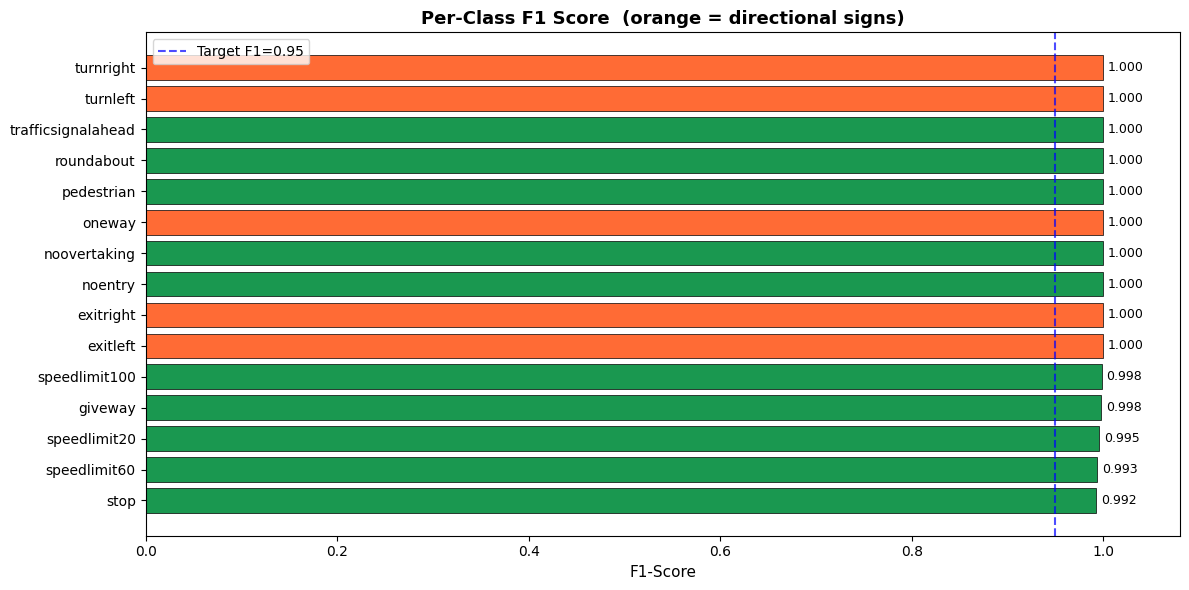

In [39]:
# ── VIZ 7: Per-class F1 score
# F1 = harmonic mean of precision and recall
# Pay attention to directional sign F1 scores — they should improve
# compared to old pipeline (which was flipping arrows incorrectly)

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
f1s    = {cls: report[cls]['f1-score'] for cls in CLASS_NAMES}
f1s    = dict(sorted(f1s.items(), key=lambda x: x[1]))

bar_colors = []
for cls in f1s.keys():
    if cls in DIRECTIONAL_CLASSES:
        bar_colors.append('#FF6B35')  # orange for directional signs
    elif list(f1s.values())[list(f1s.keys()).index(cls)] < 0.90:
        bar_colors.append('#d73027')
    elif list(f1s.values())[list(f1s.keys()).index(cls)] < 0.95:
        bar_colors.append('#fee090')
    else:
        bar_colors.append('#1a9850')

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(list(f1s.keys()), list(f1s.values()), color=bar_colors,
               edgecolor='black', linewidth=0.5)
ax.axvline(0.95, color='blue', linestyle='--', alpha=0.7, label='Target F1=0.95')
ax.set_xlabel('F1-Score', fontsize=11)
ax.set_title('Per-Class F1 Score  (orange = directional signs)', fontsize=13, fontweight='bold')
ax.set_xlim([0, 1.08])
ax.legend()
for bar, val in zip(bars, f1s.values()):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('/content/viz_f1_scores.png', dpi=150, bbox_inches='tight')
plt.show()

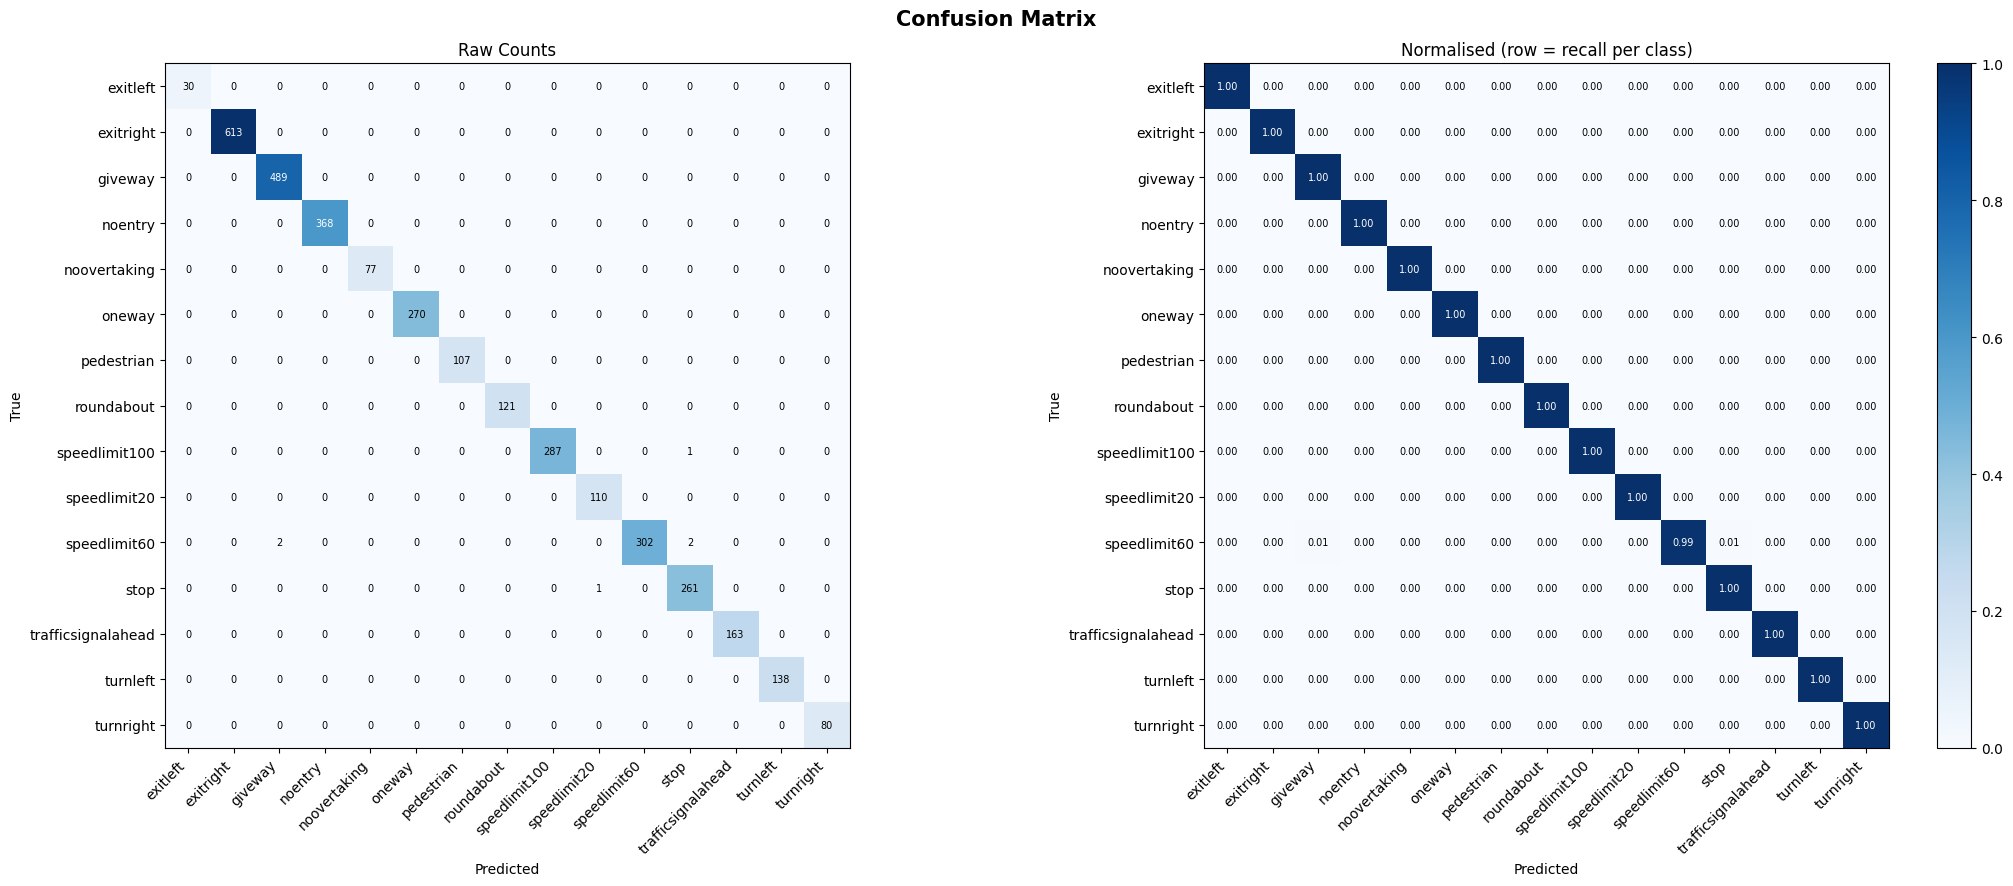


Directional sign confusion check (should be near 0):
  turnleft predicted as turnright: 0 times
  turnright predicted as turnleft: 0 times
  exitleft predicted as exitright: 0 times
  exitright predicted as exitleft: 0 times


In [40]:
# ── VIZ 8: Confusion matrix
# Rows = true labels, Columns = predicted labels
# Diagonal = correct predictions (want these high)
# Off-diagonal = mistakes
# Key to watch: turnleft↔turnright, exitleft↔exitright confusion
# These should be LOW if direction-aware augmentation worked correctly

cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.suptitle('Confusion Matrix', fontsize=15, fontweight='bold')

axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks(range(NUM_CLASSES)); axes[0].set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
axes[0].set_yticks(range(NUM_CLASSES)); axes[0].set_yticklabels(CLASS_NAMES)
axes[0].set_title('Raw Counts');  axes[0].set_xlabel('Predicted');  axes[0].set_ylabel('True')
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        axes[0].text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=7,
                     color='white' if cm[i,j] > cm.max()/2 else 'black')

im = axes[1].imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=axes[1])
axes[1].set_xticks(range(NUM_CLASSES)); axes[1].set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
axes[1].set_yticks(range(NUM_CLASSES)); axes[1].set_yticklabels(CLASS_NAMES)
axes[1].set_title('Normalised (row = recall per class)');  axes[1].set_xlabel('Predicted');  axes[1].set_ylabel('True')
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        axes[1].text(j, i, f'{cm_norm[i,j]:.2f}', ha='center', va='center', fontsize=7,
                     color='white' if cm_norm[i,j] > 0.5 else 'black')

plt.tight_layout()
plt.savefig('/content/viz_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Check directional class confusion specifically
print('\nDirectional sign confusion check (should be near 0):')
dir_pairs = [('turnleft','turnright'), ('exitleft','exitright')]
for cls_a, cls_b in dir_pairs:
    if cls_a in class_to_idx and cls_b in class_to_idx:
        i, j = class_to_idx[cls_a], class_to_idx[cls_b]
        print(f'  {cls_a} predicted as {cls_b}: {cm[i,j]} times')
        print(f'  {cls_b} predicted as {cls_a}: {cm[j,i]} times')

Wrong: 6 / 3422  (0.2%)


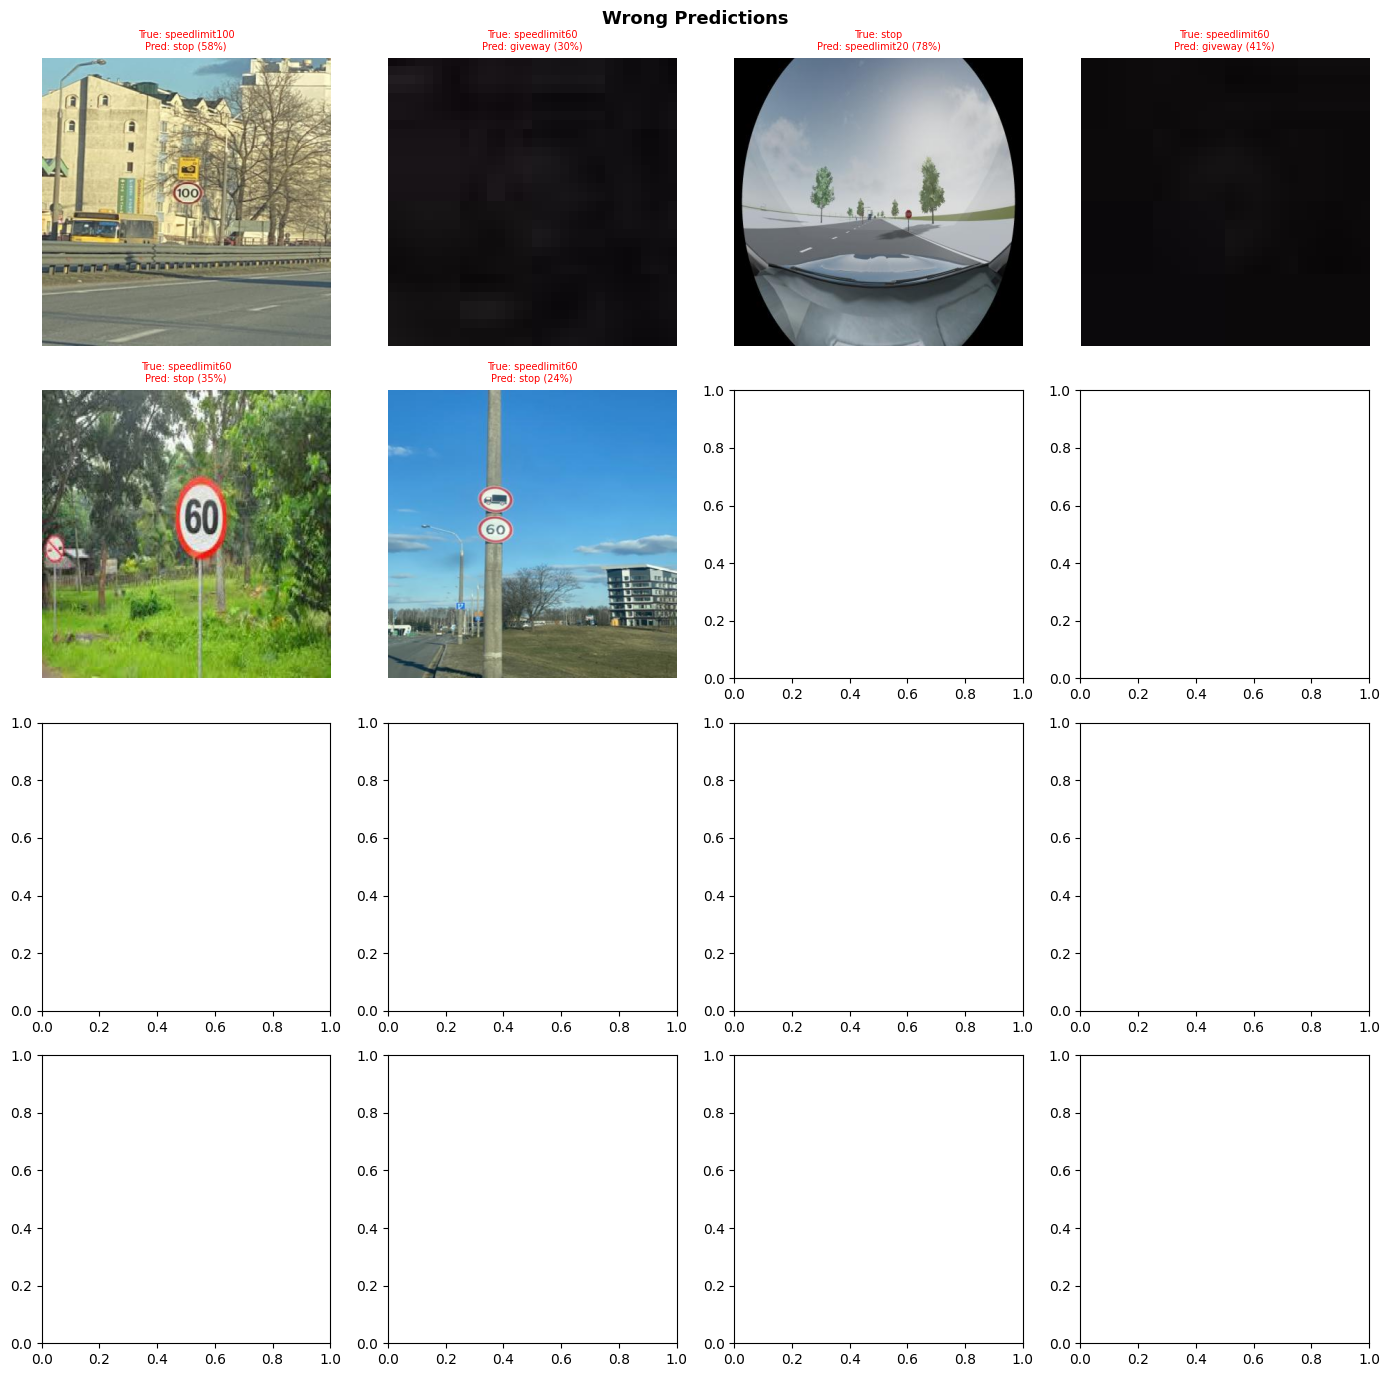

In [41]:
# ── VIZ 9: Wrong predictions
wrong_idxs = np.where(y_pred != y_true)[0]
print(f'Wrong: {len(wrong_idxs)} / {len(y_true)}  ({len(wrong_idxs)/len(y_true)*100:.1f}%)')

if len(wrong_idxs) > 0:
    picks = random.sample(list(wrong_idxs), min(16, len(wrong_idxs)))
    fig, axes = plt.subplots(4, 4, figsize=(14, 14))
    fig.suptitle('Wrong Predictions', fontsize=13, fontweight='bold')
    for ax, idx in zip(axes.flatten(), picks):
        ax.imshow(Image.open(test_paths[idx]).convert('RGB'))
        ax.set_title(
            f'True: {CLASS_NAMES[y_true[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]} ({y_prob[idx][y_pred[idx]]:.0%})',
            fontsize=7, color='red'
        )
        ax.axis('off')
    plt.tight_layout()
    plt.savefig('/content/viz_wrong_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## Step 10: Prediction Demo

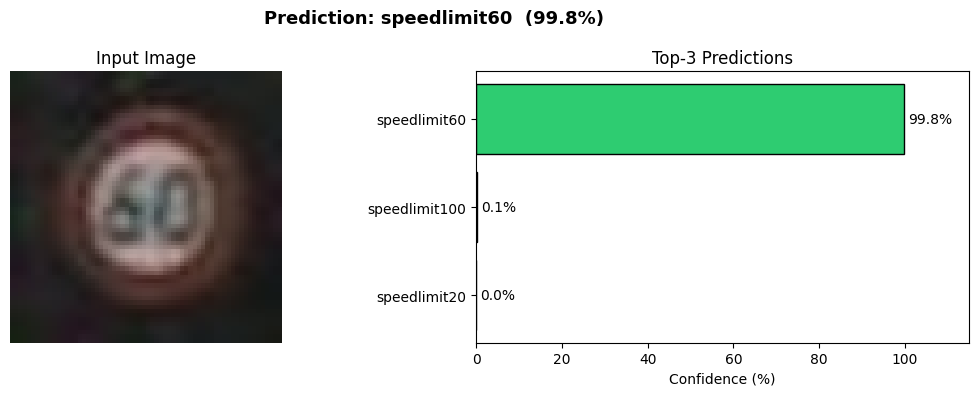

[1] True: speedlimit60          Pred: speedlimit60          CORRECT


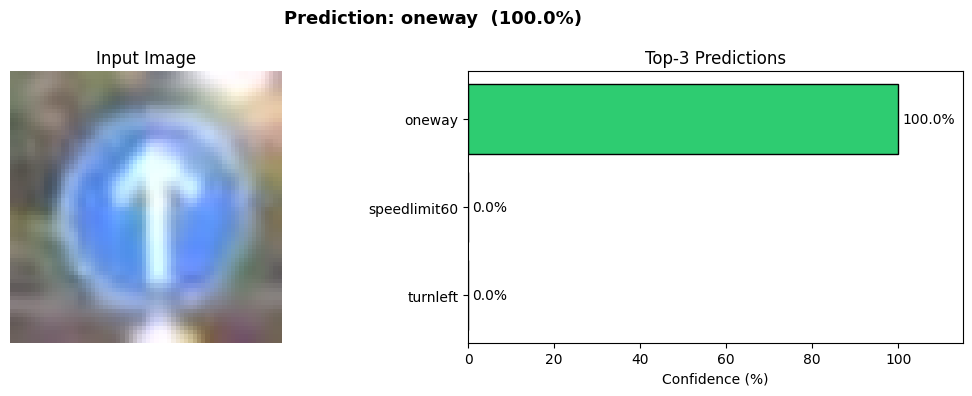

[2] True: oneway                Pred: oneway                CORRECT


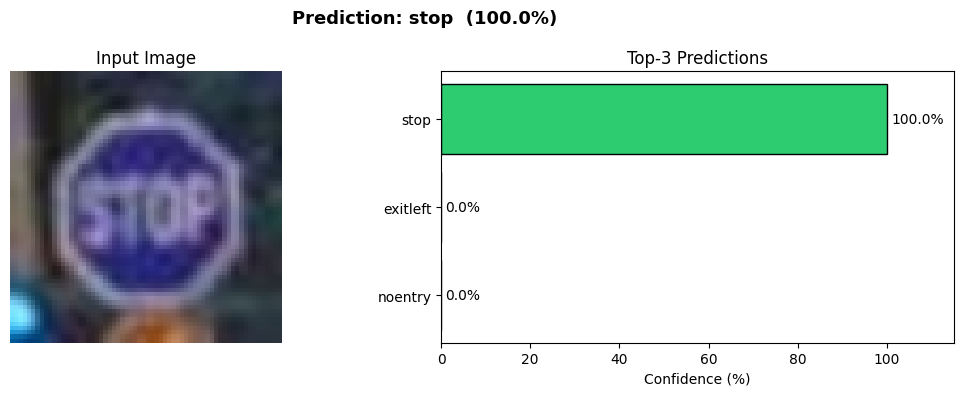

[3] True: stop                  Pred: stop                  CORRECT


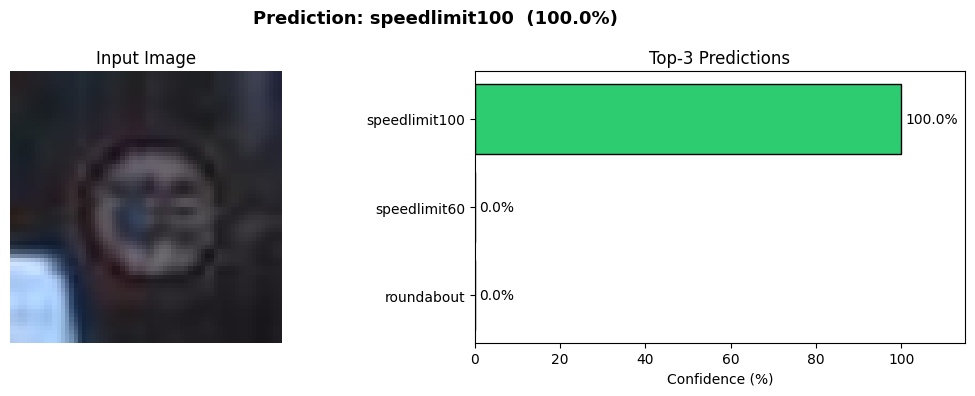

[4] True: speedlimit100         Pred: speedlimit100         CORRECT


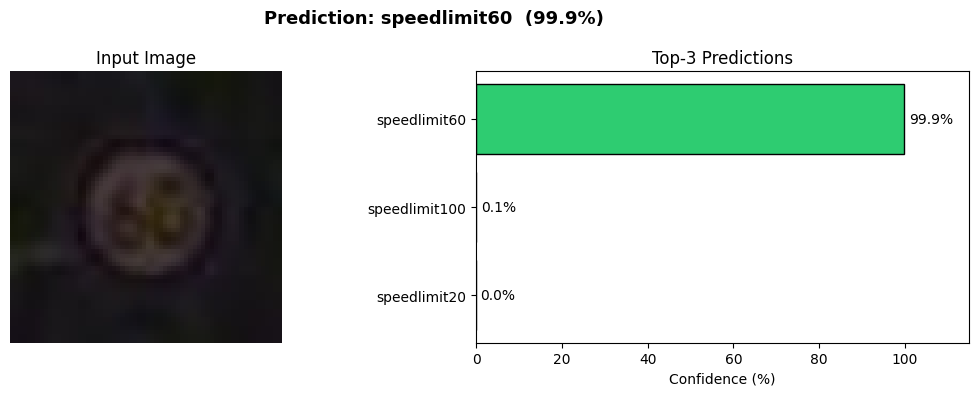

[5] True: speedlimit60          Pred: speedlimit60          CORRECT


In [42]:
def predict(model, image_path, class_names, img_size=64):
    """Load one image, run the model, show top-3 predictions."""
    img   = Image.open(image_path).convert('RGB').resize((img_size, img_size))
    arr   = np.array(img, dtype=np.float32) / 255.0
    batch = np.expand_dims(arr, 0)                  # (H,W,3) → (1,H,W,3)
    probs = model.predict(batch, verbose=0)[0]       # (15,)
    top3  = np.argsort(probs)[::-1][:3]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].imshow(img);  axes[0].axis('off');  axes[0].set_title('Input Image')

    t_labels = [class_names[i] for i in top3]
    t_confs  = [probs[i] * 100 for i in top3]
    colors   = ['#2ecc71', '#95a5a6', '#95a5a6']
    axes[1].barh(t_labels[::-1], t_confs[::-1], color=colors[::-1], edgecolor='black')
    axes[1].set_xlabel('Confidence (%)');  axes[1].set_title('Top-3 Predictions');  axes[1].set_xlim([0, 115])
    for i, v in enumerate(t_confs[::-1]):
        axes[1].text(v + 1, i, f'{v:.1f}%', va='center', fontsize=10)

    plt.suptitle(f'Prediction: {t_labels[0]}  ({t_confs[0]:.1f}%)', fontsize=13, fontweight='bold')
    plt.tight_layout();  plt.show()
    return t_labels[0]


# Run on 5 random test images
for i, idx in enumerate(random.sample(range(len(test_paths)), 5)):
    true_cls = CLASS_NAMES[y_true[idx]]
    pred_cls = predict(best_model, test_paths[idx], CLASS_NAMES, IMG_SIZE)
    result   = 'CORRECT' if pred_cls == true_cls else 'WRONG'
    print(f'[{i+1}] True: {true_cls:<20}  Pred: {pred_cls:<20}  {result}')

---
## Step 11: Save Results

In [43]:
# Save training history CSV
pd.DataFrame(history.history).to_csv(f'{MODEL_DIR}/training_history.csv', index=False)

# Save class name mapping
with open(f'{MODEL_DIR}/class_names.json', 'w') as f:
    json.dump({'classes': CLASS_NAMES, 'class_to_idx': class_to_idx}, f, indent=2)

print('Files in MODEL_DIR:')
for p in Path(MODEL_DIR).iterdir():
    print(f'  {p.name}')

print(f'\nFinal Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'Best Val  Accuracy  : {max(hist["val_accuracy"]):.4f}')

Files in MODEL_DIR:
  best_model.keras
  training_history.csv
  class_names.json

Final Test Accuracy : 0.9982  (99.82%)
Best Val  Accuracy  : 0.9986


In [44]:
# Download model and class names to your computer
from google.colab import files

files.download(BEST_MODEL_PATH)
files.download(f'{MODEL_DIR}/class_names.json')

print(f'Downloading: {BEST_MODEL_PATH}')
print(f'Downloading: {MODEL_DIR}/class_names.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: /content/models/best_model.keras
Downloading: /content/models/class_names.json
